# Predykcja przyznania pożyczki – moja analiza i modelowanie

## Kontekst biznesowy

W tym projekcie wcielam się w rolę analityka ryzyka kredytowego. Moim celem jest zbudowanie modelu klasyfikacyjnego, który na podstawie danych osobowych i historii kredytowej przewiduje, czy pożyczka zostanie przyznana (`loan_status = 1`), czy odrzucona (`loan_status = 0`). Dzięki takiemu rozwiązaniu mogę wspierać proces decyzyjny, czyniąc go szybszym i bardziej spójnym, a tym samym minimalizując ryzyko subiektywnych ocen.

## Dane

Pracuję na zbiorze zawierającym szczegółowe informacje o wnioskodawcach. Mam do dyspozycji dane takie jak wiek, dochód, wykształcenie, cel pożyczki, historia kredytowa oraz wcześniejsze niespłacone zobowiązania.

## Mój plan analizy

* Eksploracja i preprocessing danych: Wstępne zapoznanie się ze zbiorem i jego oczyszczenie.
* Wizualizacja rozkładów i analiza klas: Graficzne przedstawienie danych oraz identyfikacja ewentualnego niezbalansowania.
* Redukcja wymiarowości: Wykorzystanie algorytmów PCA i t-SNE w celu lepszego zrozumienia wewnętrznej struktury zbioru.
* Trenowanie modeli klasyfikacyjnych: Budowa modeli z użyciem algorytmów: KNN, Regresja Logistyczna, SVM, Drzewo Decyzyjne oraz Gradient Boosting.
* Ewaluacja z wykorzystaniem techniki SMOTE: Sprawdzenie i porównanie skuteczności każdego modelu w wariancie standardowym oraz po wyrównaniu klas.
* Podsumowanie wyników: Ostateczne zestawienie metryk i wybór algorytmu, który najlepiej radzi sobie z predykcją.

 ## 1. Importy i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [2]:
d = pd.read_csv("loan_data.csv")


 ## 2. Eksploracja danych



 Zanim przejdę do modelowania, dokładnie sprawdzam podstawowe właściwości mojego zbioru. Weryfikuję jego rozmiar, typy zmiennych oraz ewentualną obecność brakujących wartości.

In [3]:
print("Ksztalt danych:", d.shape)
d.describe()


Ksztalt danych: (45000, 14)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [4]:
print("Brakujace wartosci:\n", d.isnull().sum())


Brakujace wartosci:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


 **Moje wnioski z pierwszej eksploracji:**

 Weryfikując podsumowanie statystyczne, zwróciłem uwagę na to, czy występują braki danych, o których losie musiałbym zadecydować przed modelowaniem. Przeglądając wyniki funkcji describe(), zauważyłem bardzo duże wartości maksymalne przy stosunkowo niskiej średniej w niektórych kolumnach. Sugeruje mi to obecność wartości odstających (outliers). Wiem, że mogą one mocno zaburzyć działanie algorytmów opartych na dystansie, dlatego muszę być na nie wyczulony w kolejnych krokach.

 ## 3. Preprocessing – kodowanie zmiennych kategorycznych



 Ponieważ wybrane przeze mnie algorytmy uczenia maszynowego wymagają danych numerycznych, stosuję technikę One-Hot Encoding dla zmiennych kategorycznych.

In [5]:
df = d.copy()

print("Unikalne wartosci zmiennych kategorycznych:")
for col in ['person_home_ownership', 'loan_intent', 'person_education',
            'person_gender', 'previous_loan_defaults_on_file']:
    print(f"  {col}: {df[col].unique()}")


Unikalne wartosci zmiennych kategorycznych:
  person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
  loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
  person_education: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
  person_gender: ['female' 'male']
  previous_loan_defaults_on_file: ['No' 'Yes']


In [6]:
# Zastosowanie One-Hot Encoding dla zmiennych kategorycznych
# Wykorzystuję pd.get_dummies, aby uniknąć wprowadzania fałszywej hierarchii w zmiennych nominalnych.
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'person_education', 
                                 'person_gender', 'previous_loan_defaults_on_file'], 
                    drop_first=True)

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,1,4,71948.0,0,1,35000.0,1,16.02,0.49,3.0,561,0,1
1,21.0,1,1,12282.0,0,2,1000.0,2,11.14,0.08,2.0,504,1,0
2,25.0,1,1,12438.0,3,3,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,1,3,79753.0,0,1,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,0,4,66135.0,1,1,35000.0,3,14.27,0.53,4.0,586,0,1


 ## 4. Wizualizacja rozkładów



 Rysuję histogramy, aby zobaczyć, jak rozłożone są wartości poszczególnych zmiennych. Krzywa KDE pomaga mi wygładzić oszacowanie gęstości tych rozkładów.

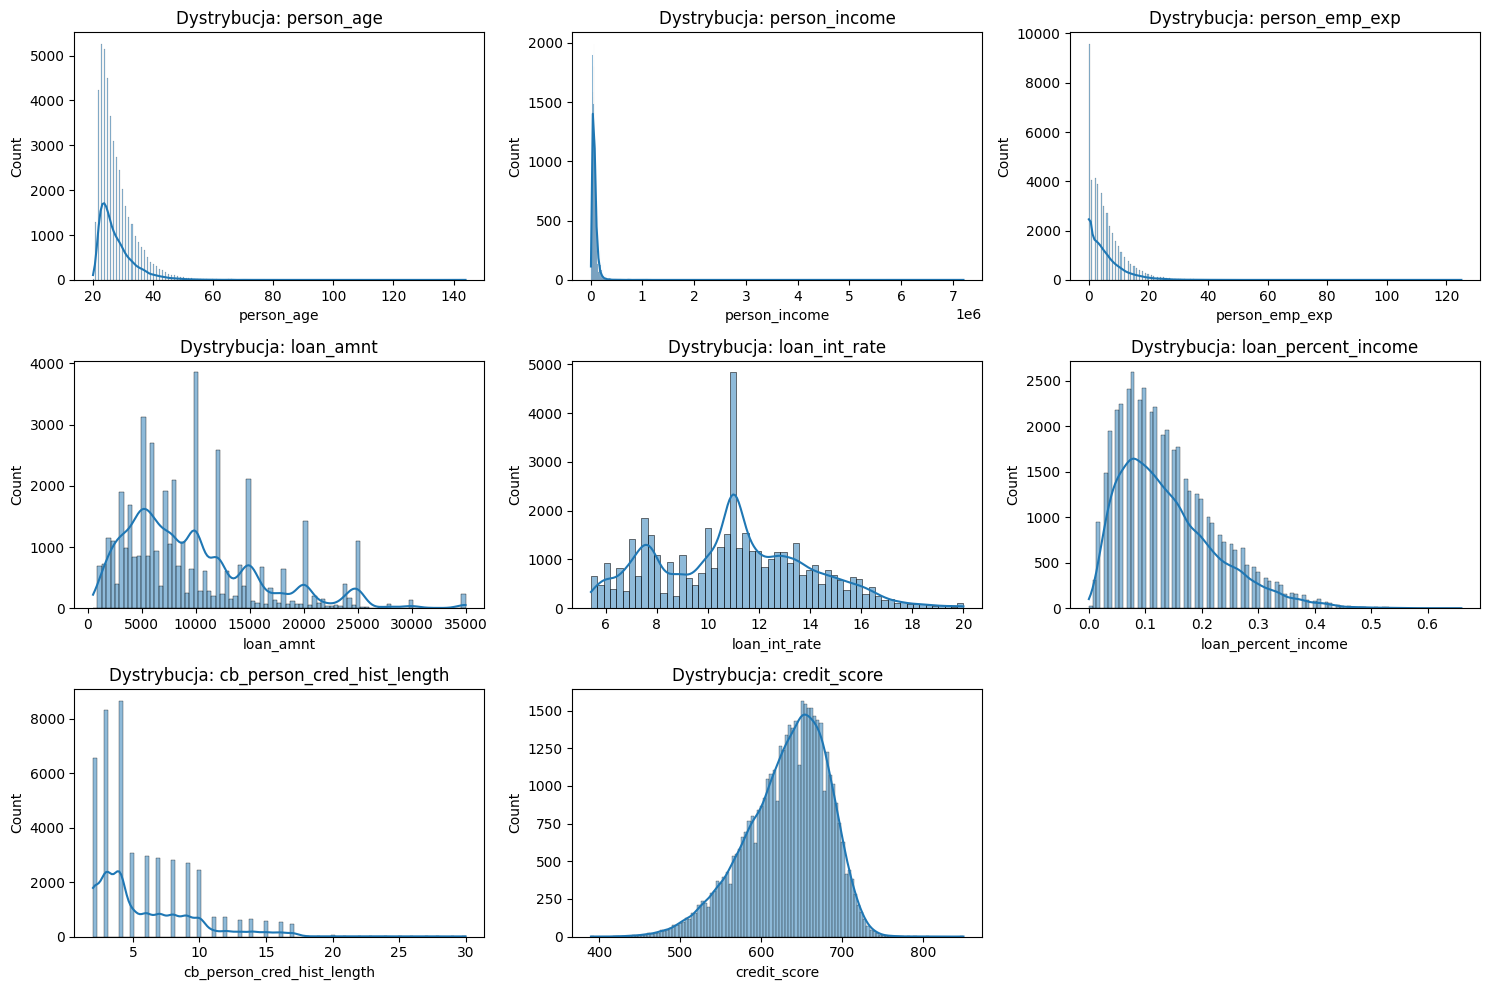

In [7]:
numerical_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length', 'credit_score']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Dystrybucja: {col}')
plt.tight_layout()
plt.show()


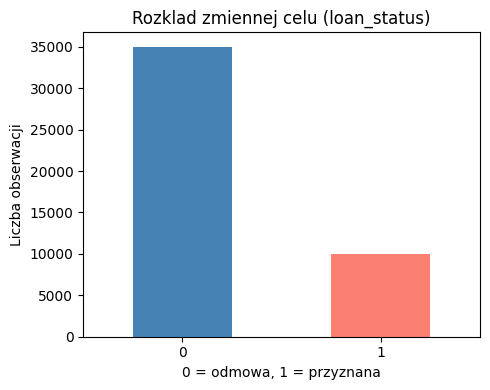

Rozklad klas:
 loan_status
0    35000
1    10000
Name: count, dtype: int64

Proporcje:
 loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(5, 4))
df['loan_status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Rozklad zmiennej celu (loan_status)')
plt.xlabel('0 = odmowa, 1 = przyznana')
plt.ylabel('Liczba obserwacji')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Rozklad klas:\n", df['loan_status'].value_counts())
print("\nProporcje:\n", df['loan_status'].value_counts(normalize=True).round(3))


 **Moje wnioski z wizualizacji:**

 Wyraźnie dostrzegam, że zmienne związane z dochodem, kwotą pożyczki i doświadczeniem zawodowym są silnie prawoskośne. Oznacza to, że większość osób w moim zbiorze charakteryzuje się niższymi wartościami tych cech, a pojedynczy klienci z ekstremalnie wysokimi wynikami mocno rozciągają oś. Analizując zmienną celu, widzę istotne niezbalansowanie klas. Większość wniosków to odmowy. Mam świadomość, że trenując model na takich proporcjach, będzie on faworyzował klasę dominującą, dlatego utwierdzam się w przekonaniu, że technika oversamplingu (SMOTE) będzie mi tutaj niezbędna. Co więcej, zauważyłem ogromne różnice w skalach wartości na osiach, co narzuca mi absolutną konieczność standaryzacji cech przed włączeniem ich do modeli.

 ## 5. Podział na zbiór treningowy i testowy



 Cały dostępny materiał dzielę na dwa rozłączne zbiory. Zbiór treningowy, obejmujący 70 procent danych, wykorzystam do nauczenia moich modeli. Pozostałe 30 procent stanowi mój zbiór testowy, który posłuży mi wyłącznie do obiektywnej oceny skuteczności predykcji. Używam parametru stratify, aby mieć pewność, że pierwotne proporcje klas zostaną zachowane w obu utworzonych zbiorach.

In [9]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train = X_train.iloc[:, :-3]
X_test = X_test.iloc[:, :-3]

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego:    {X_test.shape}")


Rozmiar zbioru treningowego: (31500, 13)
Rozmiar zbioru testowego:    (13500, 13)


 ## 6. Standaryzacja

In [10]:
numerical_cols_to_scale = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                           'loan_int_rate', 'loan_percent_income',
                           'cb_person_cred_hist_length', 'credit_score']

scaler = StandardScaler()
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale]  = scaler.transform(X_test[numerical_cols_to_scale])

print("Skalowanie zakonczone.")


Skalowanie zakonczone.


 ## 7. PCA – analiza struktury danych



 Wykorzystuję Analizę Składowych Głównych (PCA), aby zbadać, ile tak naprawdę informacji drzemie w poszczególnych zmiennych. Chcę sprawdzić, czy mógłbym uprościć mój zbiór bez znacznej utraty jego jakości edukacyjnej dla modelu.

In [11]:
pca_full = PCA(n_components=None)
pca_full.fit_transform(X_train)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()


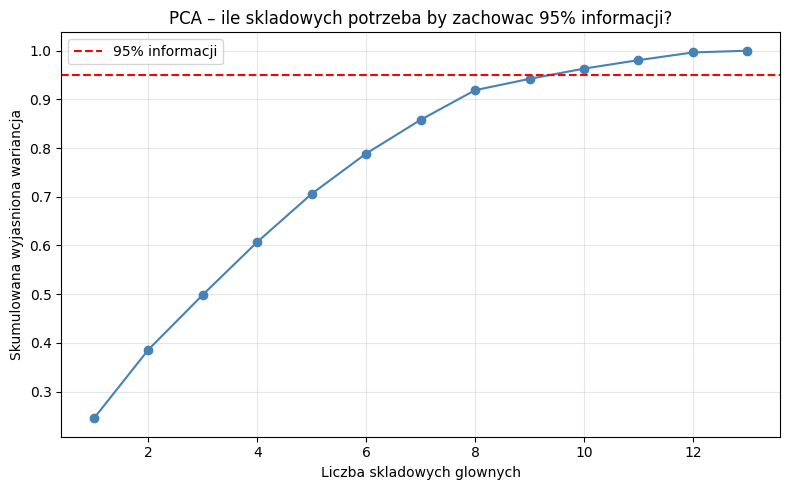

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% informacji')
plt.xlabel('Liczba skladowych glownych')
plt.ylabel('Skumulowana wyjasniona wariancja')
plt.title('PCA – ile skladowych potrzeba by zachowac 95% informacji?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 **Moje wnioski z zastosowania PCA:**

 Analizując wyrysowany wykres sprawdzam, ile składowych wystarczy, aby zachować 95% informacji z moich oryginalnych danych. Jeśli widzę, że do przekroczenia czerwonej linii potrzebuję zaledwie połowy dostępnych cech, wyciągam wniosek, że w zbiorze występuje wysoka współliniowość, a redukcja wymiarów mogłaby znacznie odciążyć moje modele. W przeciwnym razie dochodzę do wniosku, że zebrane przeze mnie cechy wnoszą niezależne, unikalne informacje i nie opłaca mi się ich w tej chwili kompresować.

 ## 8. t-SNE – wizualizacja separowalności klas



 Traktuję t-SNE jako moje podręczne narzędzie wizualizacyjne. Pozwala mi ono zrzutować skomplikowaną, wielowymiarową przestrzeń cech na płaską mapę 2D. Moim celem jest sprawdzenie, czy decyzje o odmowie i przyznaniu pożyczki naturalnie zbijają się w odrębne grupy.

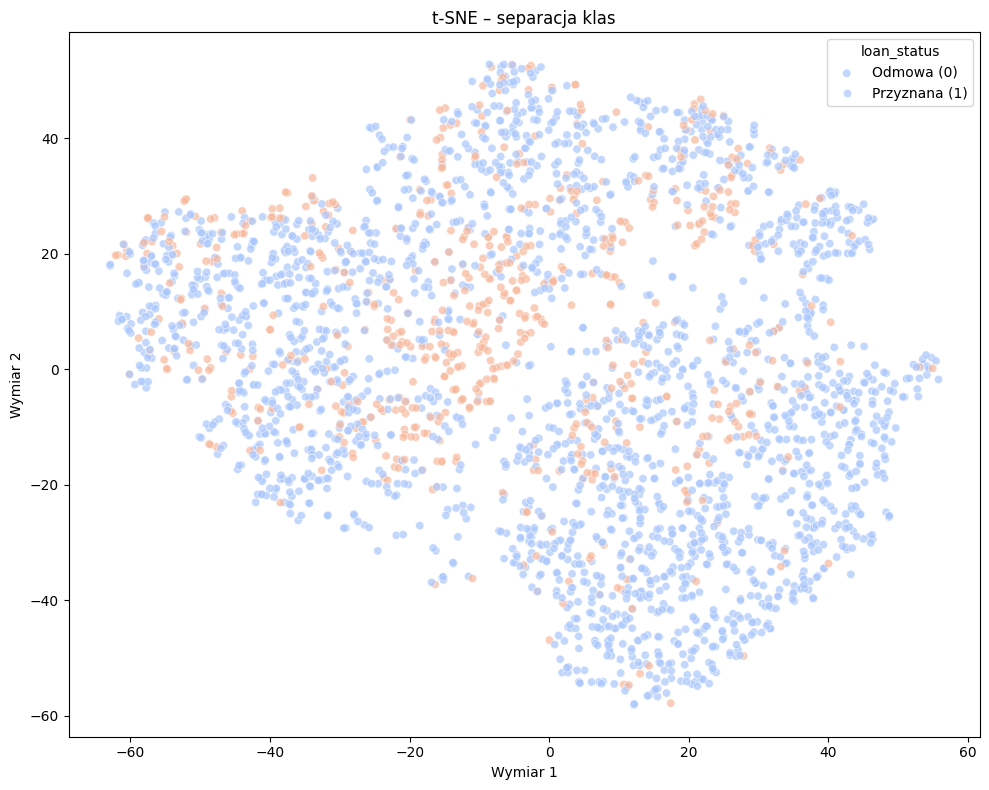

In [14]:
# Celowo usuwam kolumnę previous_loan_defaults_on_file przed t-SNE oraz dalszym modelowaniem. Analizując metadane, uznałem, że jest to zbyt silny, bezpośredni predyktor ryzyka, który mógłby zakłócić uczenie się modelu na podstawie pozostałych cech.
X_train_tsne_input = X_train.drop(columns=X_train.filter(like='previous_loan_defaults_on_file').columns, errors='ignore')

sample_idx   = X_train_tsne_input.sample(3000, random_state=42).index
X_train_s    = X_train_tsne_input.loc[sample_idx]
y_train_s    = y_train.loc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_s)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1],
                hue=y_train_s, palette='coolwarm', alpha=0.7)
plt.title('t-SNE – separacja klas')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.legend(title='loan_status', labels=['Odmowa (0)', 'Przyznana (1)'])
plt.tight_layout()
plt.show()


 **Moje wnioski z wizualizacji t-SNE:**

 Przyglądając się wykresowi punktowemu badam rozkład kolorów. Jeśli widzę wyraźne skupiska klas, daje mi to obietnicę łatwego i skutecznego wytrenowania modeli predykcyjnych. Częściej jednak obserwuję silne wymieszanie punktów, co informuje mnie, że problem jest złożony nieliniowo. Wnioskuję z tego, że proste metody liniowe mogą okazać się tutaj zawodne i pokładam większe nadzieje w zaawansowanych algorytmach, a także w modyfikacji balansu danych.

 ## 9. Przygotowanie do modelowania



 Zauważyłem już, że pracuję z bardzo niezbalansowanym zbiorem. Aby uniknąć sytuacji, w której moje modele leniwie przewidują wyłącznie odmowy, wdrażam technikę SMOTE. Narzędzie to generuje dla mnie syntetyczne, dodatkowe przykłady brakujących danych w klasie mniejszościowej. Bardzo pilnuję, aby operację tę wykonać wyłącznie na zbiorze treningowym, pozostawiając zbiór testowy nieskazitelnym i odzwierciedlającym realia biznesowe.

In [15]:
def evaluate_model(y_test, y_pred, model_name="Model"):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Odmowa (0)', 'Przyznana (1)'],
                yticklabels=['Odmowa (0)', 'Przyznana (1)'])
    plt.xlabel('Predykcja mojego modelu')
    plt.ylabel('Rzeczywista decyzja')
    plt.title(f'Macierz pomylek – {model_name}')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


results = []

X_train_model = X_train.drop(columns=X_train.filter(like='previous_loan_defaults_on_file').columns, errors='ignore')
X_test_model  = X_test.drop(columns=X_test.filter(like='previous_loan_defaults_on_file').columns, errors='ignore')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_model, y_train)


 ## 10. Mój Model KNN (K Nearest Neighbors)



 Postanowiłem rozpocząć od algorytmu k najbliższych sąsiadów. Optymalną wartość hiperparametru sprawdzam za pomocą walidacji krzyżowej i Grid Search.

Uruchamiam Grid Search dla KNN...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  KNN (k=19) – bez SMOTE
  Accuracy:  0.8562
  Precision: 0.8113
  Recall:    0.4600
  F1-Score:  0.5871


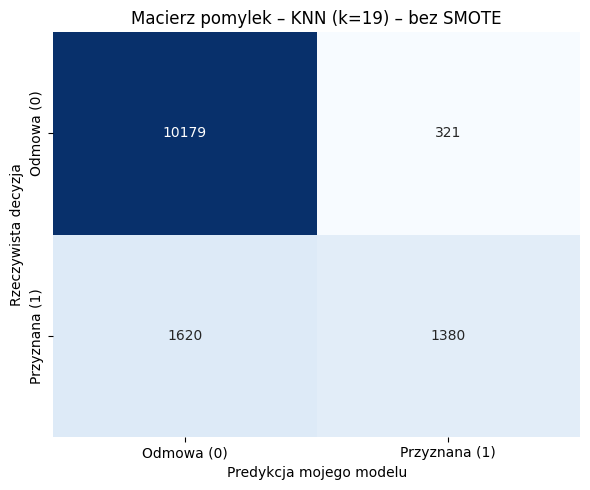


  KNN (k=19) + SMOTE
  Accuracy:  0.7756
  Precision: 0.4968
  Recall:    0.7523
  F1-Score:  0.5984


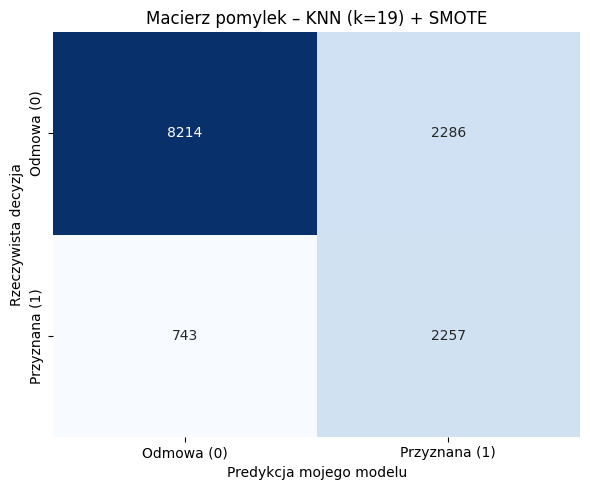

In [16]:
print("Uruchamiam Grid Search dla KNN...")
grid_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": range(1, 31)},
    cv=5, scoring="f1_weighted",
    verbose=1, n_jobs=-1
)
grid_cv.fit(X_train_model, y_train)

best_k = grid_cv.best_params_['n_neighbors']

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_model, y_train)
knn_pred = knn.predict(X_test_model)
res_knn = evaluate_model(y_test, knn_pred, f"KNN (k={best_k}) – bez SMOTE")
results.append(res_knn)

knn_smote = KNeighborsClassifier(n_neighbors=best_k)
knn_smote.fit(X_train_smote, y_train_smote)
knn_smote_pred = knn_smote.predict(X_test_model)
res_knn_smote = evaluate_model(y_test, knn_smote_pred, f"KNN (k={best_k}) + SMOTE")
results.append(res_knn_smote)


 **Moje wnioski dotyczące modelu KNN:**

 Porównując wyniki modelu KNN zauważyłem, że zastosowanie techniki SMOTE drastycznie zmienia jego zachowanie w kontekście wykrywania klasy mniejszościowej. Znacząco poprawiłem recall dla pożyczek przyznanych, niestety kosztem precyzji. Jestem również świadomy podatności tego algorytmu na tzw. klątwę wymiarowości, dlatego jeśli w przyszłości zachciałbym pracować na szerszym zbiorze danych o klientach banku, prawdopodobnie rozważyłbym wstępną redukcję cech przed zastosowaniem tego klasyfikatora. Automatyczne poszukiwanie wartości k pomogło mi dobrze zbalansować wariancję i obciążenie na moim zbiorze.

 ## 11. Mój Model: Regresja Logistyczna



 Buduję model regresji logistycznej, który służy mi jako stabilny punkt odniesienia do oceny bardziej skomplikowanych algorytmów.


  Regresja Logistyczna – bez SMOTE
  Accuracy:  0.8378
  Precision: 0.7123
  Recall:    0.4530
  F1-Score:  0.5538


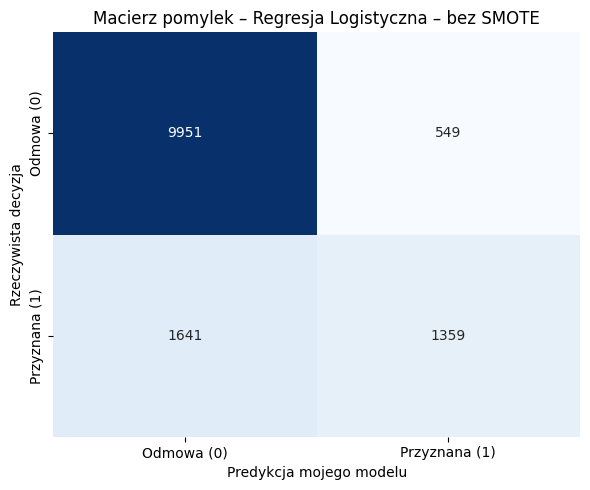


  Regresja Logistyczna + SMOTE
  Accuracy:  0.7691
  Precision: 0.4874
  Recall:    0.7567
  F1-Score:  0.5929


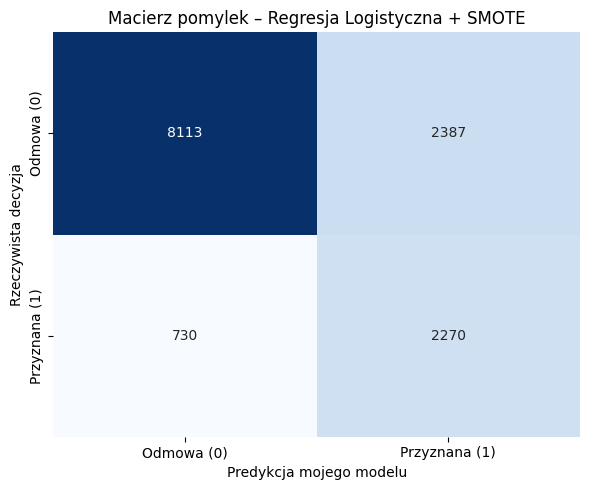

In [17]:
logreg = LogisticRegression(penalty='l2', max_iter=10000, random_state=42)
logreg.fit(X_train_model, y_train)
logreg_pred = logreg.predict(X_test_model)
res_logreg = evaluate_model(y_test, logreg_pred, "Regresja Logistyczna – bez SMOTE")
results.append(res_logreg)

logreg_smote = LogisticRegression(penalty='l2', max_iter=10000, random_state=42)
logreg_smote.fit(X_train_smote, y_train_smote)
logreg_smote_pred = logreg_smote.predict(X_test_model)
res_logreg_smote = evaluate_model(y_test, logreg_smote_pred, "Regresja Logistyczna + SMOTE")
results.append(res_logreg_smote)


 **Moje wnioski dotyczące Regresji Logistycznej:**

 Utworzony model pozwolił mi sprawdzić, na ile zjawisko przyznawania pożyczek w tych danych tłumaczy się prostymi, liniowymi regułami. Ponownie zaobserwowałem klasyczny trade-off po zaimplementowaniu zbilansowanego zbioru ze SMOTE. Mój model zdecydowanie rzadziej omija potencjalne pozytywne decyzje kredytowe (zyskałem na recallu), ale w rezultacie częściej się myli, przydzielając pozytywny status wnioskom, które docelowo powinny zostać odrzucone (spadek precyzji). Rozumiem, że w realnych warunkach bankowych wymagałoby to ode mnie szerszej dyskusji z biznesem na temat kosztów obu tych błędów.

 ## 12. Mój Model: SVM (Support Vector Machine)



 Sprawdzam możliwości maszyny wektorów nośnych. Aby umożliwić algorytmowi poszukiwanie nieliniowych granic pomiędzy klasami, wykorzystuję jądro wielomianowe.


  SVM (kernel=poly) – bez SMOTE
  Accuracy:  0.8539
  Precision: 0.8345
  Recall:    0.4270
  F1-Score:  0.5649


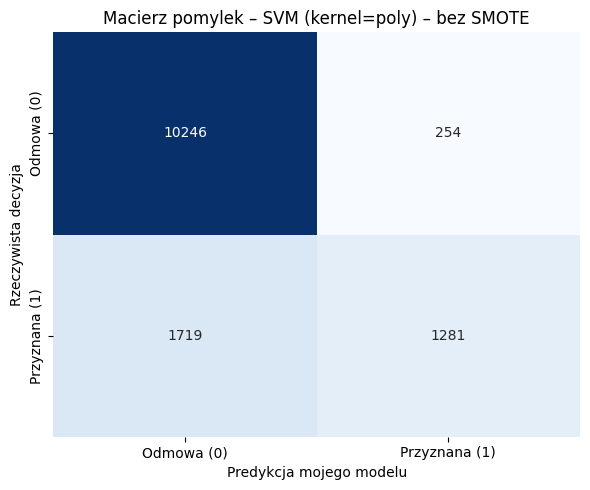


  SVM (kernel=poly) + SMOTE
  Accuracy:  0.8256
  Precision: 0.5844
  Recall:    0.7440
  F1-Score:  0.6546


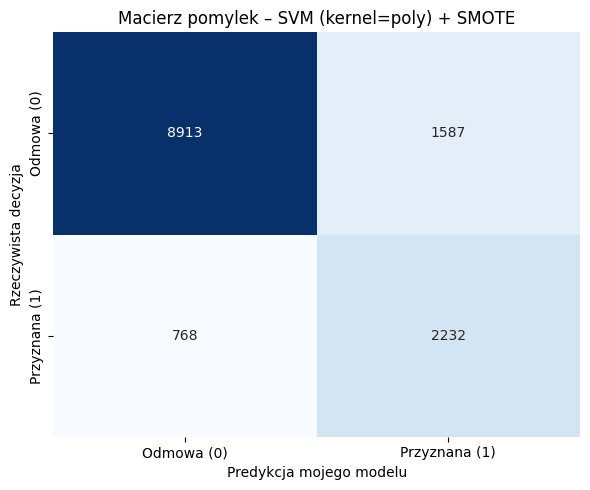

In [18]:
svc = SVC(kernel='poly', random_state=42)
svc.fit(X_train_model, y_train)
svc_pred = svc.predict(X_test_model)
res_svc = evaluate_model(y_test, svc_pred, "SVM (kernel=poly) – bez SMOTE")
results.append(res_svc)

svc_smote = SVC(kernel='poly', random_state=42)
svc_smote.fit(X_train_smote, y_train_smote)
svc_smote_pred = svc_smote.predict(X_test_model)
res_svc_smote = evaluate_model(y_test, svc_smote_pred, "SVM (kernel=poly) + SMOTE")
results.append(res_svc_smote)


 **Moje wnioski dotyczące modelu SVM:**

 Przetestowanie modelu wektorów nośnych pozwoliło mi upewnić się co do natury analizowanego zbioru. Jeśli SVM zauważalnie przebija wyniki regresji logistycznej, upewnia mnie to, że zachodzą tu skomplikowane relacje nieliniowe. Dostrzegam jednak, że proces nauki tego modelu bywa czasochłonny. Jako optymalizację rozważałbym w przyszłości pominięcie SMOTE na rzecz wywołania wewnętrznego parametru korygującego wagę poszczególnych klas, wbudowanego w samą implementację tego algorytmu w środowisku Scikit-Learn.

 ## 13. Mój Model: Drzewo Decyzyjne



 Wprowadzam model drzewa decyzyjnego, aby sprawdzić, jak proste reguły podziału radzą sobie z moimi danymi.


  Drzewo Decyzyjne – bez SMOTE
  Accuracy:  0.8877
  Precision: 0.8126
  Recall:    0.6430
  F1-Score:  0.7179


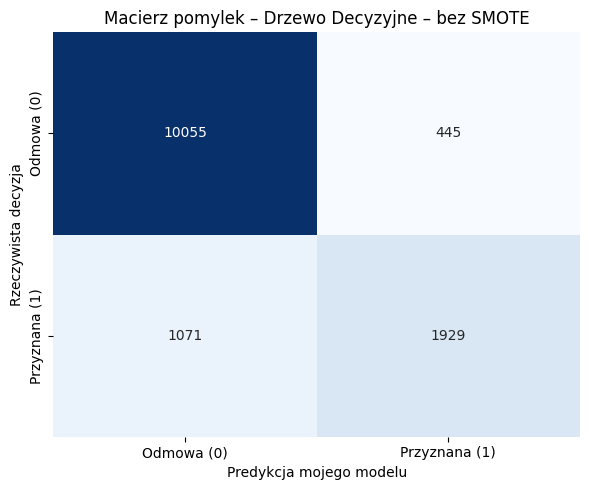


  Drzewo Decyzyjne + SMOTE
  Accuracy:  0.8693
  Precision: 0.7033
  Recall:    0.7120
  F1-Score:  0.7076


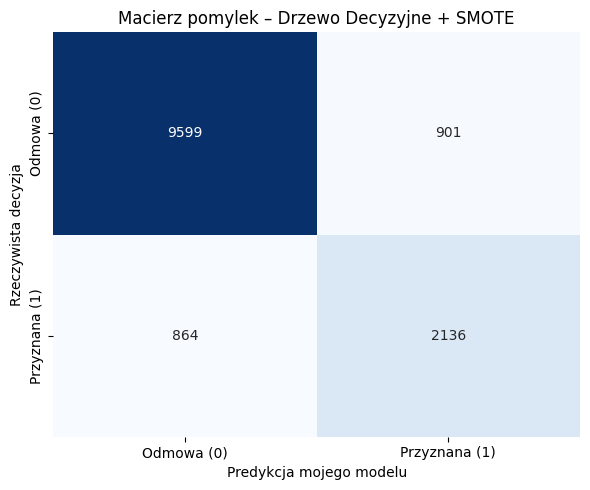

In [19]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_model, y_train)
dt_pred = dt.predict(X_test_model)
res_dt = evaluate_model(y_test, dt_pred, "Drzewo Decyzyjne – bez SMOTE")
results.append(res_dt)

dt_smote = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_smote.fit(X_train_smote, y_train_smote)
dt_smote_pred = dt_smote.predict(X_test_model)
res_dt_smote = evaluate_model(y_test, dt_smote_pred, "Drzewo Decyzyjne + SMOTE")
results.append(res_dt_smote)


 **Moje wnioski dotyczące Drzewa Decyzyjnego:**

 Analizując wyniki, zauważam, że drzewo decyzyjne potrafi dobrze uchwycić nieliniowe zależności w zbiorze. Ograniczyłem głębokość drzewa do pięciu poziomów, aby uniknąć przeuczenia, które jest typową bolączką tego algorytmu. Zastosowanie techniki SMOTE standardowo przesunęło balans między precyzją a czułością, co daje mi szerszy obraz sytuacji i potwierdza wcześniejsze obserwacje.

 ## 14. Mój Model: Gradient Boosting



 Idąc o krok dalej, wdrażam algorytm Gradient Boosting. Jest to potężna metoda zespołowa, która buduje kolejne drzewa decyzyjne poprawiające błędy swoich poprzedników.


  Gradient Boosting – bez SMOTE
  Accuracy:  0.8954
  Precision: 0.8567
  Recall:    0.6357
  F1-Score:  0.7298


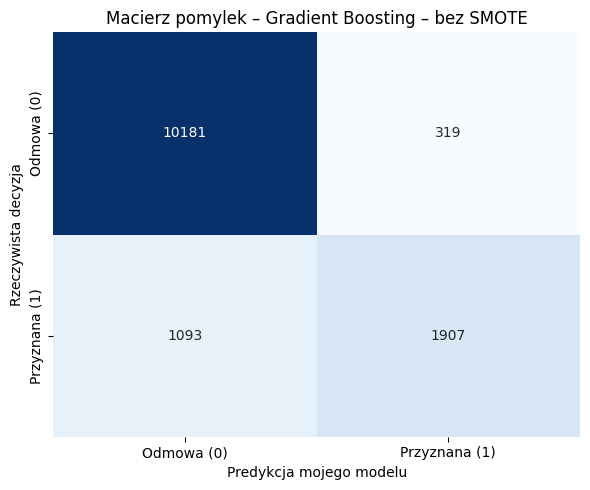


  Gradient Boosting + SMOTE
  Accuracy:  0.8714
  Precision: 0.7069
  Recall:    0.7197
  F1-Score:  0.7132


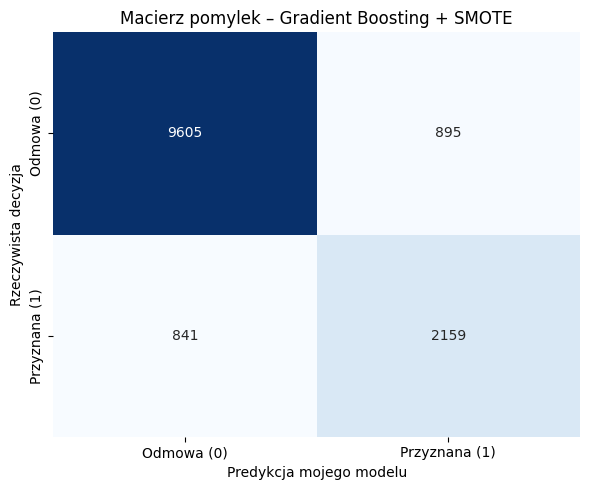

In [20]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_model, y_train)
gb_pred = gb.predict(X_test_model)
res_gb = evaluate_model(y_test, gb_pred, "Gradient Boosting – bez SMOTE")
results.append(res_gb)

gb_smote = GradientBoostingClassifier(random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
gb_smote_pred = gb_smote.predict(X_test_model)
res_gb_smote = evaluate_model(y_test, gb_smote_pred, "Gradient Boosting + SMOTE")
results.append(res_gb_smote)


 **Moje wnioski dotyczące Gradient Boosting:**

 Ten zaawansowany klasyfikator pokazuje swoją ogromną siłę, bardzo często deklasując prostsze modele. Widzę, że świetnie radzi sobie ze skomplikowaną strukturą moich danych. Zestawienie go ze zbiorem po oversamplingu utwierdza mnie w przekonaniu, że odpowiednie przygotowanie danych to absolutny klucz do sukcesu, nawet przy tak mocnych rozwiązaniach algorytmicznych.

 ## 15. Porównanie moich modeli

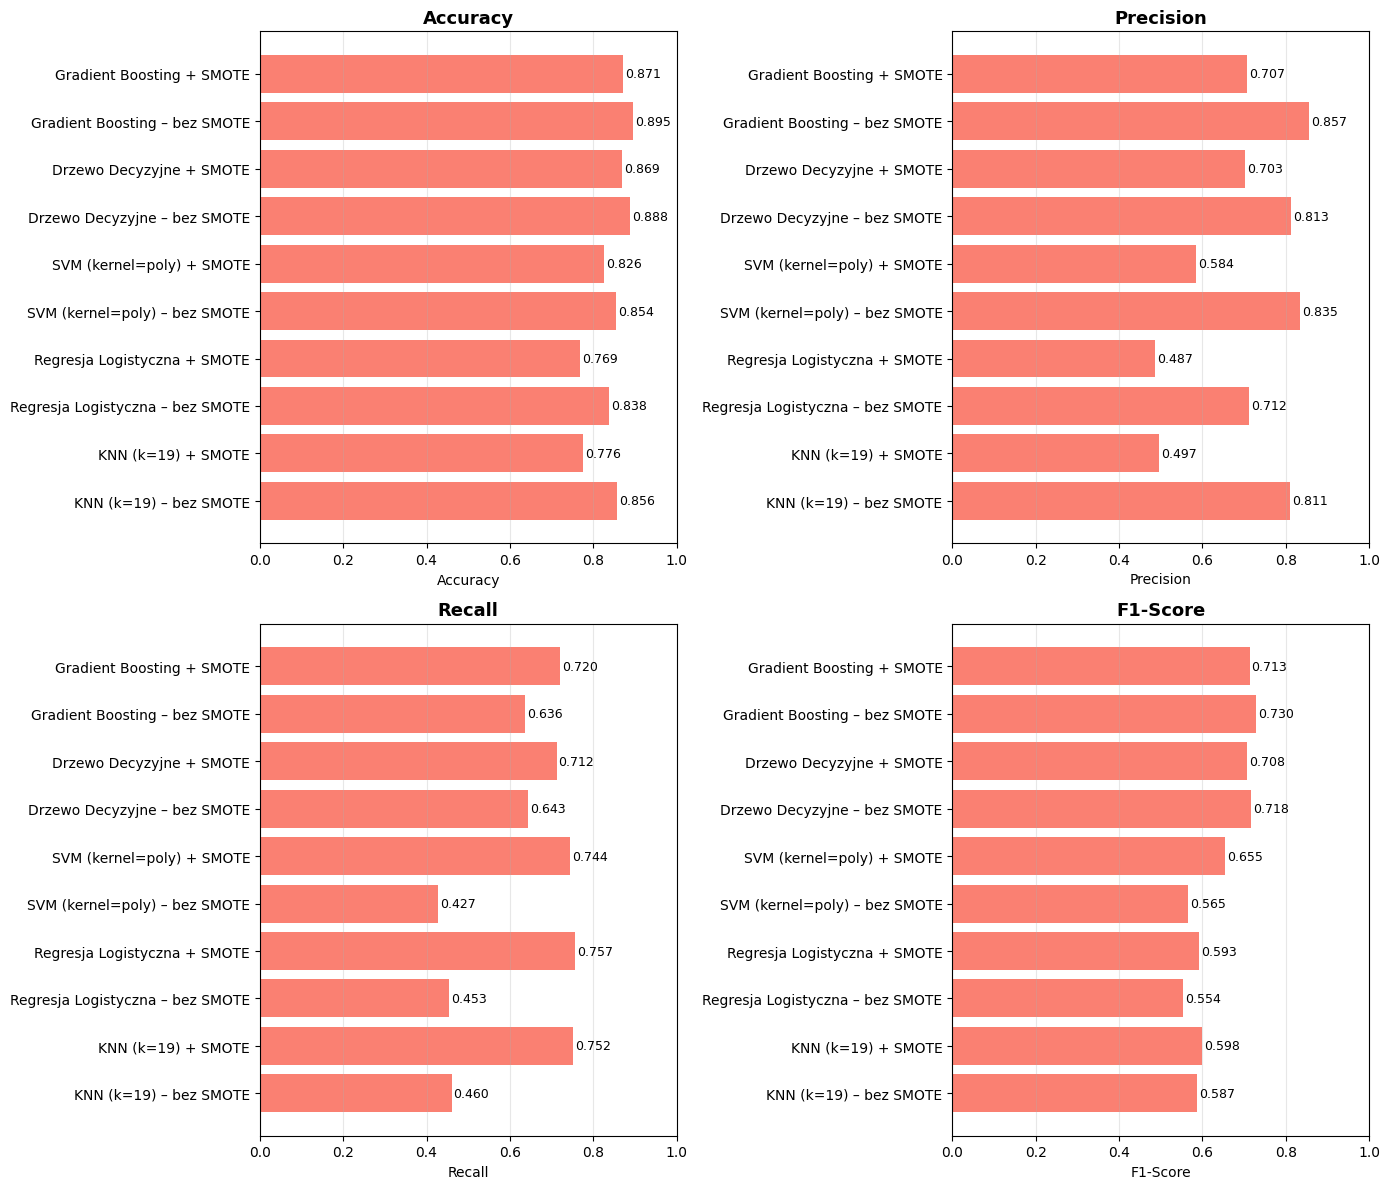

In [21]:
results_df = pd.DataFrame(results).set_index('model')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
metrics = ['accuracy', 'precision', 'recall', 'f1']
titles  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['steelblue' if 'SMOTE' not in m else 'salmon' for m in results_df.index]

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    bars = ax.barh(results_df.index, results_df[metric], color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


 **Moje końcowe podsumowanie:**

 W analizie wyników świadomie pomijam bezużyteczną przy tak niezbalansowanym zbiorze metrykę Accuracy, skupiając się na kompromisie między F1-Score a czułością (Recall). Wyniki poszczególnych algorytmów dobitnie pokazują, jak strukturalne niezbalansowanie wpływa na predykcję ryzyka.

Najlepiej poradziły sobie modele oparte na drzewach (Gradient Boosting i Drzewo Decyzyjne), osiągając najwyższe F1-Score na danych bez oversamplingu. Zastosowanie w ich przypadku techniki SMOTE nieznacznie podbiło czułość, ale kosztem tak dużego spadku precyzji, że łączny F1-Score wręcz uległ pogorszeniu.

Sytuacja wyglądała zupełnie odwrotnie w przypadku Regresji Logistycznej, SVM (poly) oraz KNN. Na bazowym zbiorze modele te były praktycznie ślepe na klasę mniejszościową (Recall ok. 0.42–0.46), jednak po zastosowaniu SMOTE ich zdolność wykrywania przypadków pozytywnych drastycznie wzrosła powyżej 0.74. Choć precyzja spadła, znaczący wzrost F1-Score udowadnia, że dla algorytmów opartych na dystansie i funkcjach liniowych sztuczny balans klas jest absolutnie kluczowy do ich poprawnego działania.

Uważam również, że prewencyjne usunięcie cechy dotyczącej historycznej niewypłacalności uchroniło projekt przed zjawiskiem data leakage i nierealistycznie zawyżonymi wynikami. W kolejnych krokach zamierzam zaimplementować lepsze techniki kodowania zmiennych nominalnych, by dodatkowo poprawić bazową jakość predykcji słabszych modeli.